In [3]:
import pandas as pd
from sklearn import datasets




In [17]:
digits = datasets.load_digits()
dir(digits)
# print(digits)


df = pd.DataFrame(digits.data,columns=digits.feature_names)
# print(df.head())

df["Target"] = digits.target
# print(df["Target"])


print(df)



      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0           0.0        0.0        5.0       13.0        9.0        1.0   
1           0.0        0.0        0.0       12.0       13.0        5.0   
2           0.0        0.0        0.0        4.0       15.0       12.0   
3           0.0        0.0        7.0       15.0       13.0        1.0   
4           0.0        0.0        0.0        1.0       11.0        0.0   
...         ...        ...        ...        ...        ...        ...   
1792        0.0        0.0        4.0       10.0       13.0        6.0   
1793        0.0        0.0        6.0       16.0       13.0       11.0   
1794        0.0        0.0        1.0       11.0       15.0        1.0   
1795        0.0        0.0        2.0       10.0        7.0        0.0   
1796        0.0        0.0       10.0       14.0        8.0        1.0   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_7  pixel_7_0  \
0           0.0        0.0      

In [ ]:
Y = df["Target"]
X = df.drop(["Target"],axis="columns")



0       0
1       1
2       2
3       3
4       4
       ..
1792    9
1793    0
1794    8
1795    9
1796    8
Name: Target, Length: 1797, dtype: int32


In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    train_size = 0.8,
    random_state = 42
)


In [ ]:
from sklearn.svm import SVC
model = SVC(kernel= 'rbf')

model.fit(
    X_train,
    Y_train
)

model.score(X_test,Y_test)
pred = model.predict(X_test)
pred

NameError: name 'X_train' is not defined

In [41]:
import joblib
joblib.dump(model,"Digit_Model")

['Digit_Model']

In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,pred)
cm

array([[33,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 28,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 33,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 34,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 46,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 46,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 35,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 33,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 29,  1],
       [ 0,  0,  0,  0,  0,  1,  0,  1,  0, 38]], dtype=int64)

<Axes: >

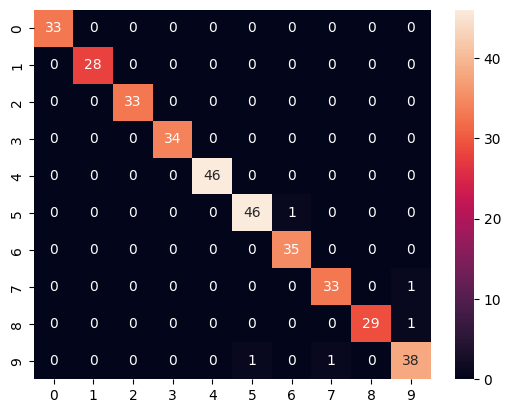

In [48]:
import seaborn as sn
sn.heatmap(cm,annot= True)

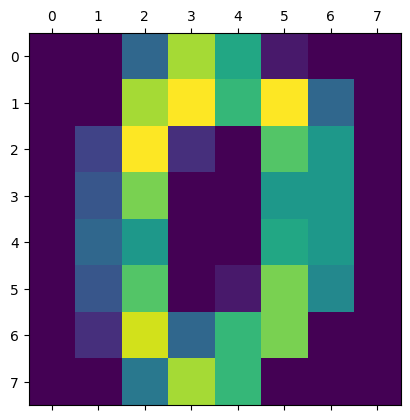

In [51]:
import matplotlib.pyplot as plt
for i in range(1):
    plt.matshow(digits.images[i])